### Quickstart: compare runs, choose a model, deploy it to a REST API

In this quickstart, you will:
- Run a hyperparameter sweep on a training script
- compare the results of the runs in the MLFlow UI
- choose the best run and register it as a model
- Deploy the model to a REST API
- Build a container image suitable for deployment to a cloud platform



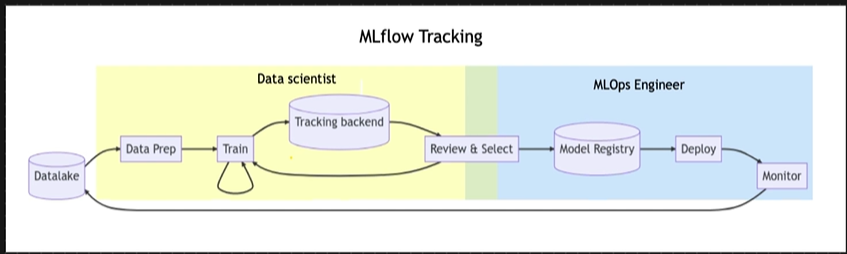

In [1]:
import keras
import numpy as np
import pandas as pd
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import mlflow
from mlflow.models import infer_signature

Matplotlib is building the font cache; this may take a moment.


In [4]:
# load the datasets
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv', sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


We will use all the features to measure what is the quality of the wine using Artificial Neural networks

In [5]:
#split the data into train, test, validation sets
train, test=train_test_split(data, test_size=0.25, random_state=42)

random_state=42: This is a seed value for the random number generator. By setting it to a specific number (in this case, 42), you ensure that the data split is reproducible. Every time you run the code with the same random_state, you'll get the same train and test sets.
When you set a random seed (like random_state=42), you are initializing the random number generator to start from a specific point. This means that every time you run your code with the same seed, the sequence of random numbers generated will be the same. Consequently, any operations that rely on randomness (like splitting data into train and test sets) will produce the same results each time.

In [6]:
train
# quality is the dependent feature, all other is independent

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
2835,6.3,0.25,0.22,3.30,0.048,41.0,161.0,0.99256,3.16,0.50,10.5,6
1157,7.8,0.30,0.29,16.85,0.054,23.0,135.0,0.99980,3.16,0.38,9.0,6
744,7.4,0.38,0.27,7.50,0.041,24.0,160.0,0.99535,3.17,0.43,10.0,5
1448,7.4,0.16,0.49,1.20,0.055,18.0,150.0,0.99170,3.23,0.47,11.2,6
3338,7.2,0.27,0.28,15.20,0.046,6.0,41.0,0.99665,3.17,0.39,10.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4426,6.2,0.21,0.52,6.50,0.047,28.0,123.0,0.99418,3.22,0.49,9.9,6
466,7.0,0.14,0.32,9.00,0.039,54.0,141.0,0.99560,3.22,0.43,9.4,6
3092,7.6,0.27,0.52,3.20,0.043,28.0,152.0,0.99129,3.02,0.53,11.4,6
3772,6.3,0.24,0.29,13.70,0.035,53.0,134.0,0.99567,3.17,0.38,10.6,6


In [9]:
train_x=train.drop(['quality'], axis=1).values
train_y= train[['quality']].values.ravel() #.ravel(): This flattens the array into a 1-dimensional array.
print(train[['quality']].values)
print(train_y)

[[6]
 [6]
 [5]
 ...
 [6]
 [6]
 [8]]
[6 6 5 ... 6 6 8]


In [10]:
test_x=test.drop(['quality'], axis=1).values
test_y=test[['quality']].values.ravel()

In [11]:
# split this train data into train and validation
train_x, valid_x, train_y, valid_y=train_test_split(train_x, train_y, test_size=0.2, random_state=45)
signature = infer_signature(train_x,train_y)

### Why validation and testing both?
Validation
Purpose: During training, the validation set helps tune hyperparameters and make adjustments to the model to prevent overfitting.
Process: The model's performance is checked on the validation set after each training iteration. This helps in making decisions like stopping training early if the model starts to overfit.
Testing
Purpose: After the model is fully trained and validated, the test set provides a final evaluation of the model's performance.
Process: The model is evaluated on the test set to measure metrics like accuracy, precision, recall, etc. This gives an unbiased estimate of how the model will perform in real-world scenarios.
Why Both Are Important
Validation Set: Helps in fine-tuning the model during training.
Test Set: Provides a final, unbiased evaluation of the model's performance.

In [ ]:
### ANN model
def train_model(params, epochs, train_x, train_y, valid_x, valid_y, test_x, test_y):
    ### define the model architecture
    mean = np.mean(train_x, axis=0) #column wise
    variance = np.var(train_x, axis=0)
    model = keras.Sequential(
        [
            keras.Input([train_x.shape[1]]),
            keras.layers.Normalization(mean=mean, variance=variance),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(1)
        ]
    )
    #compile the model
    model.compile(optimizer=keras.optimizers.SGD(
        learning_rate=params['lr'] #lets apply different learning rates and see what is the outcome for each of these
        , momentum=params['momentum']
    ), loss='mean_squared_error',
    metrics=[keras.metrics.RootMeanSquaredError()]
    )
    # i want to play with these parameters and log into mlflow
    #hyperopt will check each combinations
    # train the ann models with lr and momentum parameters and track each of them with MLflow tracking.

In [14]:
train_x.shape[1] #11 input features

11

In [13]:
mean = np.mean(train_x, axis=0)
mean # we have 11 columns, so it gives mean 11 means. we have mean per column

array([6.85820286e+00, 2.78875085e-01, 3.34261402e-01, 6.40148060e+00,
       4.53665759e-02, 3.49409462e+01, 1.37863002e+02, 9.94037231e-01,
       3.19163717e+00, 4.89819605e-01, 1.05271523e+01])

## Theory: ANN

An Artificial Neural Network (ANN) is a key concept in machine learning. It's a computational model inspired by the way biological neural networks in the human brain work. Here are some key points about ANNs:

Structure: ANNs consist of layers of interconnected nodes (neurons). These layers typically include an input layer, one or more hidden layers, and an output layer.
Learning: ANNs learn by adjusting the weights of the connections between nodes based on the input data and the desired output. This process is known as training.
Activation Functions: Each neuron applies an activation function to its input to determine its output. Common activation functions include sigmoid, tanh, and ReLU.
Applications: ANNs are used in various applications such as image recognition, natural language processing, and predictive analytics.